In [72]:
import pyorbital
from pyorbital.orbital import Orbital
import datetime as dt
import numpy as np

import networkx as nx

from pathlib import Path
import os

from enum import Enum

from fame import *

import plotly.express as px
from matplotlib.pyplot import cm

import random


In [73]:
R_earth_km = 6371


In [74]:
# Space-Track Credentials
space_track_user = os.environ.get('SPACE_TRACK_USER'), 
space_track_password = os.environ.get('SPACE_TRACK_PW')


In [75]:
tle_file_name_json = "tles/all_tles_{}.json".format(dt.datetime.now().strftime("%Y%m%d"))
tle_file_name_txt = "tles/all_tles_{}.txt".format(dt.datetime.now().strftime("%Y%m%d"))

if Path(tle_file_name_txt).is_file():
    pass
else:
    if Path(tle_file_name_json).is_file():
        pass
    else:
        all_tles_for_today = get_gp_tles(tle_file_name_json, space_track_user, space_track_password)
    process_tles_from_json(tle_file_name_json, tle_file_name_txt)

In [76]:
# tle_file_name_txt = "all_tles_20260130.txt"


In [77]:
#tle_file_name_txt = "tles/all_tles_20260121.txt"


# min_time=dt.datetime.now(dt.timezone.utc)
# max_time=dt.datetime.now(dt.timezone.utc)+ dt.timedelta(seconds=3600*24*2)

#min_time = dt.datetime.strptime("2026-01-21 00:00:00.00000", "%Y-%m-%d %H:%M:%S.%f").replace(tzinfo=None)
min_time = dt.datetime.now(dt.timezone.utc).replace(tzinfo=None)
max_time=min_time + dt.timedelta(seconds=3600*24*2)

In [78]:
# planet_satellites = []
# 14-19 decayed

swaths_at_nadir_km = {
    "SKYSAT-A": 8, # https://www.eoportal.org/satellite-missions/skysat#SkySat.html.53, https://earth.esa.int/eogateway/missions/skysat#instruments-section
    "SKYSAT-B": 8,
    "SKYSAT-C1": 5.9,
    "SKYSAT-C2": 5.9,
    "SKYSAT-C3": 5.9,
    "SKYSAT-C4": 5.9,
    "SKYSAT-C5": 5.9,
    "SKYSAT-C6": 5.9,
    "SKYSAT-C7": 5.9,
    "SKYSAT-C8": 5.9,
    "SKYSAT-C9": 5.9,
    "SKYSAT-C10": 5.9,
    "SKYSAT-C11": 5.9,
    "SKYSAT-C12": 5.9,
    "SKYSAT-C13": 5.9,
    "PELICAN-3001": 8, # https://www.planet.com/constellations/pelican/
    "PELICAN-3009": 8,
    "PELICAN-300A": 8,
    "PELICAN-300B": 8,
    "PELICAN-5": 8,
    "PELICAN-6": 8,
    "TANAGER-4001": 18, # https://www.planet.com/constellations/tanager/
    "UMBRA-07": 8, # https://umbra.space/remote-sensing/scan-mode/
    "UMBRA-09": 8, 
    "UMBRA-10": 8,
    "UMBRA-11": 8, 
    "CAPELLA-11 (ACADIA-1)": 10, #https://support.capellaspace.com/what-are-capellas-collect-modes and https://geokom.ba/wp-content/uploads/2020/12/Capella_Space_SAR_System_Performance.pdf
    "CAPELLA-13 (ACADIA-3)": 10,
    "CAPELLA-14 (ACADIA-4)": 10,
    "CAPELLA-15 (ACADIA-5)": 10,
    "CAPELLA-16 (ACADIA-6)": 10,
    "CAPELLA-17 (ACADIA-7)": 10,
    "LOFT YAM-6": 19.8,
    "Ubotica CogniSat-6 HAMMER": 20,
    "Mission Control Persistence": 100,
    "AEROCUBE 18A": 80,
    "AEROCUBE 18B": 80,
}

flock_names = []

iceye_names = []

with open(tle_file_name_txt, 'r') as file:
    for line in file:
        # Check if the line begins with "flock"
        if line.startswith("FLOCK"):
            # .strip() removes the trailing newline character (\n)
            flock_names.append(line.strip()) 
            
with open(tle_file_name_txt, 'r') as file:
    for line in file:
        # Check if the line begins with "flock"
        if line.startswith("ICEYE"):
            # .strip() removes the trailing newline character (\n)
            iceye_names.append(line.strip()) 


            
for dove_name in flock_names:
    swaths_at_nadir_km[dove_name] =  16.4 #https://www.newspace.im/constellations/planet-labs


for iceye_name in iceye_names:
    swaths_at_nadir_km[iceye_name] =  10 
print("FIX ICEYE SWATH")


# print("HACK!")
# for sat, swath in swaths_at_nadir_km.items():
#     if swath<20:
#         swaths_at_nadir_km[sat]*=10

# dove_satellites = [
#     Satellite(dove_name, Orbital(dove_name, tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True)
#     for dove_name in flock_names
#     ]

print("DOVES OFF")

dove_satellites = []

iceye_satellites = [
    Satellite(iceye_name, Orbital(iceye_name, tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR], has_continuous_isl_to_ground=True)
    for iceye_name in iceye_names
    ]

skysat_satellites = [
    Satellite("SKYSAT-A", Orbital("SKYSAT 1", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-B", Orbital("SKYSAT 2", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C1", Orbital("SKYSAT C1", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    # Satellite("SKYSAT-C1", Orbital("SKYSAT C1", tle_file=tle_file_name_txt)),
    Satellite("SKYSAT-C2", Orbital("SKYSAT C2", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C3", Orbital("SKYSAT C3", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C4", Orbital("SKYSAT C4", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C5", Orbital("SKYSAT C5", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C6", Orbital("SKYSAT C6", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C7", Orbital("SKYSAT C7", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C8", Orbital("SKYSAT C8", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C9", Orbital("SKYSAT C9", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C10", Orbital("SKYSAT C10", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C11", Orbital("SKYSAT C11", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C12", Orbital("SKYSAT C12", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C13", Orbital("SKYSAT C13", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
]
try:
    pelican_satellites = [
        Satellite("PELICAN-3001", Orbital("PELICAN-1 3001", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-3009", Orbital("PELICAN-2 3009", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-300A", Orbital("PELICAN-3 300A", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-300B", Orbital("PELICAN-4 300B", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-5", Orbital("PELICAN-5 300C", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-6", Orbital("PELICAN-6 300D", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    ]
except KeyError as e:

    pelican_satellites = [
        Satellite("PELICAN-3001", Orbital("PELICAN 3001", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-3009", Orbital("PELICAN 3009", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-300A", Orbital("PELICAN-3", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-300B", Orbital("PELICAN-4", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-5", Orbital("PELICAN-5", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-6", Orbital("PELICAN-6", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    ]

try:
    tanager_satellites = [
        Satellite("TANAGER-4001", Orbital("TANAGER-1 4001", tle_file=tle_file_name_txt), instruments=[InstrumentType.HYPERSPECTRAL], has_continuous_isl_to_ground=True),
    ]
except KeyError as e:
    tanager_satellites = [
        Satellite("TANAGER-4001", Orbital("TANAGER 4001", tle_file=tle_file_name_txt), instruments=[InstrumentType.HYPERSPECTRAL], has_continuous_isl_to_ground=True),
    ]
# 1-6 and 8 decayed
umbra_satellites = [
    Satellite("UMBRA-07", Orbital("UMBRA-07", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("UMBRA-09", Orbital("UMBRA-09", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("UMBRA-10", Orbital("UMBRA-10", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("UMBRA-11", Orbital("UMBRA-11", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
]
capella_acadia_satellites = [
    Satellite("CAPELLA-11 (ACADIA-1)", Orbital("CAPELLA-11 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("CAPELLA-14 (ACADIA-4)", Orbital("CAPELLA-14 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("CAPELLA-13 (ACADIA-3)", Orbital("CAPELLA-13 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("CAPELLA-15 (ACADIA-5)", Orbital("CAPELLA-15 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("CAPELLA-17 (ACADIA-7)", Orbital("CAPELLA-17 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("CAPELLA-16 (ACADIA-6)", Orbital("CAPELLA-16 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
]
# Whitneys all decayes
# capella_whitney_satellites = [
#     Satellite("CAPELLA-4-WHITNEY",  Orbital("CAPELLA-4-WHITNEY")),
#     Satellite("CAPELLA-3-WHITNEY",  Orbital("CAPELLA-3-WHITNEY")),
#     Satellite("CAPELLA-6-WHITNEY",  Orbital("CAPELLA-6-WHITNEY")),
#     Satellite("CAPELLA-5-WHITNEY",  Orbital("CAPELLA-6-WHITNEY")),
#     Satellite("CAPELLA-8-WHITNEY",  Orbital("CAPELLA-8-WHITNEY")),
#     Satellite("CAPELLA-7-WHITNEY",  Orbital("CAPELLA-7-WHITNEY")),
#     Satellite("CAPELLA-10-WHITNEY", Orbital("CAPELLA-10-WHITNEY")),
#     Satellite("CAPELLA-9-WHITNEY",  Orbital("CAPELLA-9-WHITNEY")),
# ]


loft_satellites = [Satellite("LOFT YAM-6", Orbital("YAM-6", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True)]
ubotica_satellites = [Satellite("Ubotica CogniSat-6 HAMMER", Orbital("HAMMER", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True)]
mission_control_satellites = [Satellite("Mission Control Persistence", Orbital("LEMUR 2 KRISH", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),]
aerospace_corp_satellites = [
    Satellite("AEROCUBE 18A", Orbital("AEROCUBE 18A", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("AEROCUBE 18B", Orbital("AEROCUBE 18B", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),   
]

for sat in skysat_satellites:
    sat.isl_links = {s: 250 for s in dove_satellites+skysat_satellites+pelican_satellites+tanager_satellites if s!=sat }
for sat in pelican_satellites:
    sat.isl_links = {s: 250 for s in dove_satellites+skysat_satellites+pelican_satellites+tanager_satellites if s!=sat }
for sat in tanager_satellites:
    sat.isl_links = {s: 250 for s in dove_satellites+skysat_satellites+pelican_satellites+tanager_satellites if s!=sat }

for sat in umbra_satellites:
    sat.isl_links = {s: 250 for s in umbra_satellites if s!=sat }

for sat in capella_acadia_satellites:
    sat.isl_links = {s: 250 for s in capella_acadia_satellites if s!=sat }

for sat in aerospace_corp_satellites:
    sat.isl_links = {s: 250 for s in aerospace_corp_satellites if s!=sat }


FIX ICEYE SWATH
DOVES OFF


In [79]:
all_satellites = skysat_satellites+pelican_satellites+tanager_satellites+iceye_satellites+umbra_satellites+capella_acadia_satellites+loft_satellites+ubotica_satellites+mission_control_satellites
# ---------------------------------------------------------------------
# FLEET SANITIZATION FILTER 🛡️
# ---------------------------------------------------------------------
print(f"Checking {len(all_satellites)} satellites for deep space or bad data anomalies...")
sanitized_satellites = []

for sat in all_satellites:
    try:
        # Test if pyorbital can actually step across your window boundaries
        _ = sat.orbit.get_lonlatalt(min_time)
        _ = sat.orbit.get_lonlatalt(max_time)
        sanitized_satellites.append(sat)
    except (NotImplementedError, Exception):
        # Quietly discard deep space, decayed, or missing TLE matches
        print(f"   [Skipped] {sat.name} failed orbit propagation tests.")

all_satellites = sanitized_satellites
print(f"✅ Cleared {len(all_satellites)} LEO-compliant satellites for execution.")
# ---------------------------------------------------------------------

Checking 87 satellites for deep space or bad data anomalies...
   [Skipped] SKYSAT-C13 failed orbit propagation tests.
✅ Cleared 86 LEO-compliant satellites for execution.


In [80]:
for _sat in all_satellites:
    _semi_major_axis = _sat.orbit.orbit_elements.semi_major_axis * pyorbital.orbital.A
    _mean_altitude = _semi_major_axis-pyorbital.orbital.A
    _fov = 2*np.atan2(swaths_at_nadir_km[_sat.name]/2, _mean_altitude)
    _sat.instrument_fov_rad = {InstrumentType.RGB: _fov}

In [81]:
def satcolorer(sat_name):
    # Planet: shades of blue
    if "SKYSAT" in sat_name:
        return "midnightblue"
    if "PELICAN" in sat_name:
        return "mediumblue"
    if "TANAGER" in sat_name:
        return "blueviolet"
    # Black
    if "UMBRA" in sat_name:
        return "dimgray"
    # Yellow/orange
    if "CAPELLA" in sat_name:
        return "darkorange"
    # 
    if "LOFT" in sat_name:
        return "forestgreen"
    #
    if "Ubotica" in sat_name:
        return "lime"
    #
    if "Mission Control" in sat_name:
        return "orchid"
    return "red"
    
def constcolorer(constellation_name):
    # Planet: shades of blue
    if "PLANET" in constellation_name:
        return "blue"
    # Black
    if "UMBRA" in constellation_name:
        return "gray"
    # Yellow/orange
    if "CAPELLA" in constellation_name:
        return "darkorange"
    # 
    if "LOFT" in constellation_name:
        return "forestgreen"
    #
    if "Ubotica" in constellation_name:
        return "lime"
    #
    if "Mission Control" in constellation_name:
        return "orchid"
    return "red"

def satmarkerer(sat_name):
    # Planet: shades of blue
    if "SKYSAT" in sat_name:
        return "p"
    if "PELICAN" in sat_name:
        return "p"
    if "TANAGER" in sat_name:
        return "p"
    # Black
    if "UMBRA" in sat_name:
        return "D"
    # Yellow/orange
    if "CAPELLA" in sat_name:
        return "D"
    # 
    if "LOFT" in sat_name:
        return "p"
    #
    if "Ubotica" in sat_name:
        return "p"
    #
    if "Mission Control" in sat_name:
        return "p"
    return "."

satcolor = {sat.name: satcolorer(sat.name) for sat in all_satellites}

satmarker = {sat.name: satmarkerer(sat.name) for sat in all_satellites}

constcolor = {sat.name: satmarkerer(sat.name) for sat in all_satellites}


In [82]:
Rotterdam = Location(3.8, 52, 0, "Rotterdam-ish")

### Communication opportunities

In [83]:

ground_stations = [
    Location(
        -79.55,
        8.9833,
        0.028,
        "KSAT Panama",
    ),
    Location(
        -51.73363,
        64.182789,
        0,
        "KSAT Nuuk",
    ),
    Location(
        2.53219,
        -72.01243,
        0,
        "KSAT Troll",
    ),
    Location(
        142.3689,
        43.8,
        0,
        "KSAT Hokkaido",
    ),
    Location(
        103.9915,
        1.3661,
        0,
        "KSAT Singapore",
    ),
    Location(
        -70.85021,
        -52.93279,
        0,
        "KSAT Punta Arenas",
    ),
    Location(
        127.7766,
        26.4055,
        0,
        "KSAT Okinawa",
    ),
    Location(
        57.5565,
        -20.1142,
        0,
        "KSAT Mauritius",
    ),
    Location(
        22.62216,
        37.84604,
        0,
        "KSAT Nemea",
    ),
    Location(
        31.12509,
        70.36779,
        0,
        "KSAT Vardo",
    ),
    Location(
        15.39964,
        78.22875,
        0,
        "KSAT Svalbard",
    ),
]

# What is a workflow?

We had described a workflow as:
- A task or bag of tasks
- whose completion spawns other tasks (implicitly creating both a START_AFTER_END constraint, and an information dependency).

We need to handle two cases: (i) the next location is unknown and (ii) the next location is known, but there is a Boolean gate.
Do we want more complex constraints? It would be nice to have a CONCURRENT constraint. Or START_AFTER_START.
How about we stsart with the simple stuff?
We will then implement ~~two~~ three algorithms for scheduling.
- Priority heuristic
- ILP
- Network flow (as above) only for START_AFTER_END

Let's start defining the format.

A workflow is (i) a set of ObservationRequests with (ii) dependency constraints of the type START_AFTER_END, CONCURRENT, START_AFTER_START, (iii) Boolean constraints of the type START_IF_SUCCESSFUL, START_IF_FAILED (which imply START_AFTER_END dependency), and (iv) geometry constraints of the form DATA.
We distinguish the Boolean and geometry constriants because the latter does not allow early scheduling.

There is a recursive form of this. We will not use it initially, and use an interpreter to translate the unrolled form to the recursive form.

A set of (ObservationRequest, Dependency (dict with other ObsRequest as key, and obs type as value), BooleanConstraint (dict with other ObsRequest as key, and obs type as value), GeometryConstraint (dict with other ObsRequest as key, and obs type as value))

Note we are also implicitly defining an output format for observation requests' data products: these need to, at a minimum, return a boolean success, and (if required) geometric data information. That is really an execution constraint.


In [84]:
Rotterdam = Location(3.8, 52, 0, "Rotterdam-ish")

In [85]:



obs_request_initial = ObservationRequest(
    Rotterdam.lon_deg,
    Rotterdam.lat_deg,
    min_time=min_time,
    max_time=min_time+dt.timedelta(hours=4),
    alt_km=Rotterdam.alt_km,
    request_name="Initial RGB request in Rotterdam",
    min_elevation_deg=45,
    instrument=InstrumentType.RGB
    )

obs_request_followup_no = ObservationRequest(
    Rotterdam.lon_deg,
    Rotterdam.lat_deg,
    min_time=min_time,
    max_time=max_time,
    alt_km=Rotterdam.alt_km,
    request_name="Follow-up search request in Rotterdam",
    min_elevation_deg=45,
    instrument=InstrumentType.SAR
    )

obs_request_followup_yes = ObservationRequest(
    Rotterdam.lon_deg,
    Rotterdam.lat_deg,
    min_time=min_time,
    max_time=max_time,
    alt_km=Rotterdam.alt_km,
    request_name="Follow-up imaging request in Rotterdam",
    min_elevation_deg=45,
    instrument=InstrumentType.RGB
    )


In [86]:

ship_location_timeline = Timeline(name="Ship location", initial_time=min_time, initial_value=1, initial_rate=-1./10800, min_value=-100, max_value=100)


constrained_initial_observation = ConstrainedObservationRequest(
    name = "Initial observation",
    observation_request=obs_request_initial,
    success_declarer=lambda data_product: len(data_product)>0,
    is_mandatory=True,
    timeline_constraints=[],
    timeline_impacts=[TaskTimelineImpact(timeline=ship_location_timeline, time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=1.)],
)

constrained_followup_observation = ConstrainedObservationRequest(
    name = "Follow-up observation 1",
    observation_request=obs_request_followup_yes,
    task_constraints = [
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER, constrained_initial_observation),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, constrained_initial_observation, {'offset': dt.timedelta(seconds=3600*3)}),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, constrained_initial_observation, {'offset': dt.timedelta(seconds=3600*6)}),
        Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_SUCCESSFUL, constrained_initial_observation),
        Constraint(ConstraintClass.GEOMETRY, GeometryConstraintType.LLA, constrained_initial_observation),
    ],
    timeline_constraints=[TaskTimelineConstraint(timeline=ship_location_timeline, time=TaskImpactTime.PRE, type=TimelineConstraintType.GREATER_OR_EQUAL, value=0.),],
    timeline_impacts=[TaskTimelineImpact(timeline=ship_location_timeline, time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=1.),],
)

constrained_followup_search = ConstrainedObservationRequest(
    name = "Follow-up search 1",
    observation_request=obs_request_followup_no,
    task_constraints=[
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER, constrained_initial_observation),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, constrained_initial_observation, {'offset': dt.timedelta(seconds=3600*3)}),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, constrained_initial_observation, {'offset': dt.timedelta(seconds=3600*6)}),
        Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_FAILED, constrained_initial_observation),
    ],
    timeline_constraints=[TaskTimelineConstraint(timeline=ship_location_timeline, time=TaskImpactTime.PRE, type=TimelineConstraintType.LESSER_OR_EQUAL, value=0),],
    timeline_impacts=[TaskTimelineImpact(timeline=ship_location_timeline, time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=1.)],
)

constrained_followup_observation_later = ConstrainedObservationRequest(
    name = "Follow-up observation 2",
    observation_request=obs_request_followup_yes,
    task_constraints = [
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, constrained_followup_observation, {'offset': dt.timedelta(seconds=3600*3)}),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, constrained_followup_observation, {'offset': dt.timedelta(seconds=3600*6)}),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, constrained_followup_search, {'offset': dt.timedelta(seconds=3600*3)}),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, constrained_followup_search, {'offset': dt.timedelta(seconds=3600*6)}),
        Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_SUCCESSFUL, constrained_followup_observation),
        Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_SUCCESSFUL, constrained_followup_search),
        Constraint(ConstraintClass.GEOMETRY, GeometryConstraintType.LLA, constrained_followup_observation),
        Constraint(ConstraintClass.GEOMETRY, GeometryConstraintType.LLA, constrained_followup_search),
    ],
    timeline_constraints=[TaskTimelineConstraint(timeline=ship_location_timeline, time=TaskImpactTime.PRE, type=TimelineConstraintType.GREATER_OR_EQUAL, value=0),],
    timeline_impacts=[TaskTimelineImpact(timeline=ship_location_timeline, time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=1.)],
    schedule_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: True, ConstraintClass.SUCCESS: True, ConstraintClass.GEOMETRY: True},
)

constrained_followup_search_later = ConstrainedObservationRequest(
    name = "Follow-up search 2",
    observation_request=obs_request_followup_no,
    task_constraints = [
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, constrained_followup_observation, {'offset': dt.timedelta(seconds=3600*3)}),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, constrained_followup_observation, {'offset': dt.timedelta(seconds=3600*6)}),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, constrained_followup_search, {'offset': dt.timedelta(seconds=3600*3)}),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, constrained_followup_search, {'offset': dt.timedelta(seconds=3600*6)}),
        Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_FAILED, constrained_followup_observation),
        Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_FAILED, constrained_followup_search),
    ],
    timeline_constraints=[TaskTimelineConstraint(timeline=ship_location_timeline, time=TaskImpactTime.PRE, type=TimelineConstraintType.LESSER_OR_EQUAL, value=0),],
    timeline_impacts=[TaskTimelineImpact(timeline=ship_location_timeline, time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=1.)],
)

constrained_followup_observation_later2 = ConstrainedObservationRequest(
    name = "Follow-up observation 3",
    observation_request=obs_request_followup_yes,
    task_constraints = [
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, constrained_followup_observation_later, {'offset': dt.timedelta(seconds=3600*3)}),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, constrained_followup_observation_later, {'offset': dt.timedelta(seconds=3600*6)}),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, constrained_followup_search_later, {'offset': dt.timedelta(seconds=3600*3)}),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, constrained_followup_search_later, {'offset': dt.timedelta(seconds=3600*6)}),
        Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_SUCCESSFUL, constrained_followup_observation_later),
        Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_SUCCESSFUL, constrained_followup_search_later),
        Constraint(ConstraintClass.GEOMETRY, GeometryConstraintType.LLA, constrained_followup_observation_later),
        Constraint(ConstraintClass.GEOMETRY, GeometryConstraintType.LLA, constrained_followup_search_later),
    ],
    timeline_constraints=[TaskTimelineConstraint(timeline=ship_location_timeline, time=TaskImpactTime.PRE, type=TimelineConstraintType.GREATER_OR_EQUAL, value=0),],
    timeline_impacts=[TaskTimelineImpact(timeline=ship_location_timeline, time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=1.)],
    schedule_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: True, ConstraintClass.SUCCESS: True, ConstraintClass.GEOMETRY: True},
)

constrained_followup_search_later2 = ConstrainedObservationRequest(
    name = "Follow-up search 3",
    observation_request=obs_request_followup_no,
    task_constraints = [
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, constrained_followup_observation_later, {'offset': dt.timedelta(seconds=3600*3)}),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, constrained_followup_observation_later, {'offset': dt.timedelta(seconds=3600*6)}),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, constrained_followup_search_later, {'offset': dt.timedelta(seconds=3600*3)}),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, constrained_followup_search_later, {'offset': dt.timedelta(seconds=3600*6)}),
        Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_FAILED, constrained_followup_observation_later),
        Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_FAILED, constrained_followup_search_later),
    ],
    timeline_constraints=[TaskTimelineConstraint(timeline=ship_location_timeline, time=TaskImpactTime.PRE, type=TimelineConstraintType.LESSER_OR_EQUAL, value=0),],
    timeline_impacts=[TaskTimelineImpact(timeline=ship_location_timeline, time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=1.)],
)



workflow = Workflow(
    constrained_observation_requests=[
        constrained_initial_observation,
        constrained_followup_observation,
        constrained_followup_search,
        constrained_followup_observation_later,
        constrained_followup_search_later,
        constrained_followup_observation_later2,
        constrained_followup_search_later2,
    ],
    timelines = [ship_location_timeline,],
    )

   [Scheduler] WG: MultiDiGraph with 7 nodes and 37 edges
   [Scheduler] Nodes to visit: [Initial observation]
   [Scheduler] Current request: Initial observation
   [Scheduler] This request is still in play, let's revisit it
   [Scheduler] This request has 2 children: [Follow-up observation 1, Follow-up search 1]
Skipping task constraints for child Follow-up observation 1, currently unscheduled
Skipping task constraints for child Follow-up search 1, currently unscheduled
   [Scheduler] This request has 0 parents: []
Found opportunities from time 2026-06-15 21:23:24.535607 to 2026-06-16 01:23:24.535607: {Request Initial RGB request in Rotterdam_trimmed: {PELICAN-3009: [Pass start: 2026-06-15 22:48:21.505861, highest: 2026-06-15 22:49:16.355148, fall: 2026-06-15 22:50:09.694965], PELICAN-300B: [Pass start: 2026-06-15 21:41:02.541663, highest: 2026-06-15 21:42:04.082062, fall: 2026-06-15 21:42:55.671011], PELICAN-5: [Pass start: 2026-06-15 21:45:07.948270, highest: 2026-06-15 21:46:08.36

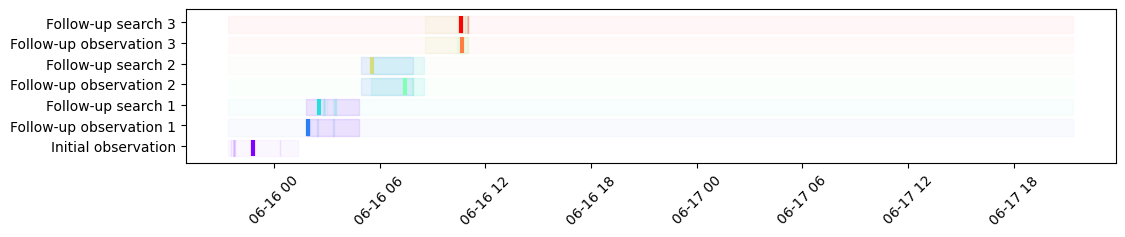

In [87]:
wg, tg = build_workflow_graph(workflow=workflow)

wg = greedy_schedule_workflow(workflow_graph=wg, timeline_graph=tg, satellites=all_satellites)

for request in workflow.constrained_observation_requests:
    if request in wg.nodes():
        print(f"Request {request}: opportunity {request.observation_opportunity}")
    else:
        print(f"Request {request} was not scheduled")
# wg.nodes[obs_request_followup_no]

plot_workflow_schedule(wg)

In [88]:
wg_ilp, tg_ilp = build_workflow_graph(workflow=workflow)


In [89]:
wg_ilp = ilp_schedule_workflow(workflow_graph=wg_ilp, timeline_graph=tg_ilp, satellites=all_satellites, verbose=3)


   [Scheduler] WG: MultiDiGraph with 7 nodes and 37 edges
CPLEX not found, trying SCIP
    [Scheduler] Solver status 0; objective value =41.54487174662269
    [Scheduler]  Initial observation_PELICAN-3009_Pass start: 2026-06-15 22:48:21.505861, highest: 2026-06-15 22:49:16.355148, fall: 2026-06-15 22:50:09.694965  =  1.0
    [Scheduler]  Follow-up observation 1_Ubotica CogniSat-6 HAMMER_Pass start: 2026-06-16 02:54:20.037317, highest: 2026-06-16 02:54:25.699444, fall: 2026-06-16 02:54:31.361573  =  1.0
    [Scheduler]  Follow-up observation 3_SKYSAT-C10_Pass start: 2026-06-16 01:29:59.520812, highest: 2026-06-16 01:30:46.902911, fall: 2026-06-16 01:31:38.232434  =  1.0
    [Scheduler]  Follow-up search 3_ICEYE-X39_Pass start: 2026-06-17 21:17:19.996495, highest: 2026-06-17 21:17:56.667052, fall: 2026-06-17 21:18:32.854234  =  1.0

    [Scheduler] Problem solved in 14383 milliseconds
    [Scheduler] Problem solved in 483 iterations
    [Scheduler] Problem solved in 1 branch-and-bound no

In [90]:

for request in workflow.constrained_observation_requests:
    if request in wg_ilp.nodes():
        print(f"Request {request}: opportunity {request.observation_opportunity}")
    else:
        print(f"Request {request} was not scheduled")
# wg.nodes[obs_request_followup_no]

Request Initial observation: opportunity Observation  at 2026-06-15 22:49:16.355148 by PELICAN-3009 with InstrumentType.RGB. Look angle 260.16249274276674 | 73.03211374964991 az/dec deg, zenith angle 103.66592403030968 deg, range 472.01425076044376 km, duration 0:01:00
Request Follow-up observation 1: opportunity Observation  at 2026-06-16 02:54:25.699444 by Ubotica CogniSat-6 HAMMER with InstrumentType.RGB. Look angle 260.01430005511617 | 45.170500552958835 az/dec deg, zenith angle 94.10489295936482 deg, range 581.5984302495182 km, duration 0:01:00
Request Follow-up search 1: opportunity Observation  at 2026-06-16 02:31:57.087667 by ICEYE-X25 with InstrumentType.SAR. Look angle 259.2253742141832 | 64.22964206995395 az/dec deg, zenith angle 96.33707058450862 deg, range 437.11811210794616 km, duration 0:01:00
Request Follow-up observation 2: opportunity Observation  at 2026-06-16 07:24:51.604582 by SKYSAT-C2 with InstrumentType.RGB. Look angle 283.71015247484104 | 79.5099493744124 az/de

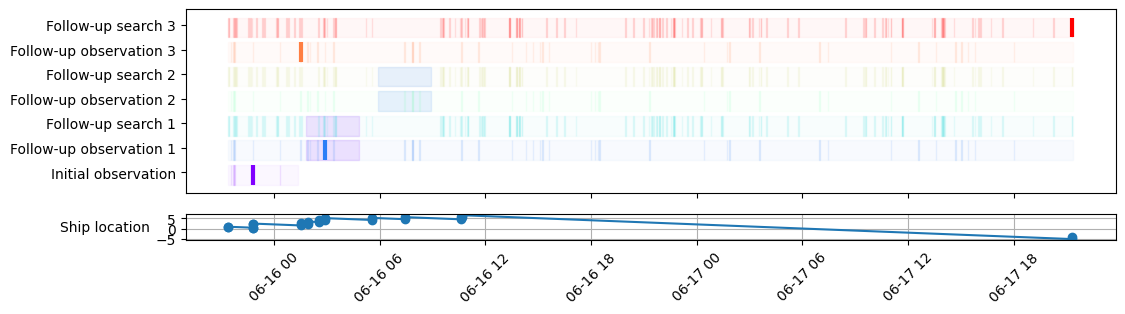

In [91]:


plot_workflow_schedule(wg_ilp, tg_ilp)


In [92]:
dt_h = 3

ship_location_timeline_longer = Timeline(name="Do we know where the ship is?", initial_time=min_time, initial_value=1, initial_rate=-1./10800, min_value=-100, max_value=100)


constrained_initial_observation_longer = ConstrainedObservationRequest(
    name = "Initial observation",
    observation_request=obs_request_initial,
    success_declarer=lambda data_product: len(data_product)>0,
    is_mandatory=True,
    timeline_constraints=[],
    timeline_impacts=[TaskTimelineImpact(timeline=ship_location_timeline_longer, time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=1.)],
)

workflow_longer_reqs = [constrained_initial_observation_longer]


# If the prior is successful, do a SAR request
for h_ix in list(range(dt_h,24,dt_h)):

    obs_task_constraints = [
            Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, constrained_initial_observation_longer, {'offset': dt.timedelta(seconds=3600*h_ix)}),
            Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, constrained_initial_observation_longer, {'offset': dt.timedelta(seconds=3600*(h_ix+dt_h))}),
            # Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_SUCCESSFUL, workflow_longer_reqs[-1]), # Start if the previous search was successful
            # Constraint(ConstraintClass.GEOMETRY, GeometryConstraintType.LLA, workflow_longer_reqs[-1]),
        ]
    # if len(workflow_longer_reqs)>1:
    #     obs_task_constraints.append(
    #         Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_SUCCESSFUL, workflow_longer_reqs[-2]), # Start if the previous observation was successful
    #     )
    #     obs_task_constraints.append(
    #         Constraint(ConstraintClass.GEOMETRY, GeometryConstraintType.LLA, workflow_longer_reqs[-2]),
    #     )

    constrained_followup_observation_later = ConstrainedObservationRequest(
        name="Follow-up observation {}".format(int(h_ix/dt_h)),
        observation_request=obs_request_followup_yes,
        task_constraints = obs_task_constraints,
        schedule_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: True, ConstraintClass.SUCCESS: True, ConstraintClass.GEOMETRY: True},
        dispatch_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: True, ConstraintClass.SUCCESS: True, ConstraintClass.GEOMETRY: True},
        success_declarer=lambda data_product: len(data_product)>0,
        timeline_constraints=[TaskTimelineConstraint(timeline=ship_location_timeline_longer, time=TaskImpactTime.PRE, type=TimelineConstraintType.GREATER_OR_EQUAL, value=0),],
        timeline_impacts=[TaskTimelineImpact(timeline=ship_location_timeline_longer, time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=1.)],

    )

    srch_task_constraints = [
            Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, constrained_initial_observation_longer, {'offset': dt.timedelta(seconds=3600*h_ix)}),
            Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, constrained_initial_observation_longer, {'offset': dt.timedelta(seconds=3600*(h_ix+dt_h))}),
            # Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_FAILED, workflow_longer_reqs[-1]), # Start if the previous search was successful
        ]
    # if len(workflow_longer_reqs)>1:
    #     srch_task_constraints.append(
    #         Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_FAILED, workflow_longer_reqs[-2]), # Start if the previous observation failed (or was not scheduled)
    #     )

    # If the prior fails, do a search
    constrained_followup_search_later = ConstrainedObservationRequest(
        name="Follow-up search {}".format(int(h_ix/dt_h)),
        observation_request=obs_request_followup_no,
        task_constraints = srch_task_constraints,
        schedule_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: True, ConstraintClass.SUCCESS: True, ConstraintClass.GEOMETRY: True},
        dispatch_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: True, ConstraintClass.SUCCESS: True, ConstraintClass.GEOMETRY: True},
        success_declarer=lambda data_product: len(data_product)>0,
        timeline_constraints=[TaskTimelineConstraint(timeline=ship_location_timeline_longer, time=TaskImpactTime.PRE, type=TimelineConstraintType.LESSER_OR_EQUAL, value=0),],
        timeline_impacts=[TaskTimelineImpact(timeline=ship_location_timeline_longer, time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=1.)],

    )

    workflow_longer_reqs.append(constrained_followup_observation_later)
    workflow_longer_reqs.append(constrained_followup_search_later)

def longer_timeline_updater(current_time: dt.datetime, requests: list[ConstrainedObservationRequest], timelines: list[Timeline], max_time_without_observations: dt.timedelta=dt.timedelta(seconds=10800)):
    # What time is it?
    # Did we have a successful search or imaging in the recent past?
    # If we did, set timeline start to 1
    # If we did not, set timeline start to 0
    # Keep the current rate
    ship_position_is_known = False
    for current_request in requests:
        if (current_request.completed is True):
            if (current_request.successful_execution is True):
                if (current_time-current_request.observation_opportunity.time)<max_time_without_observations:
                    ship_position_is_known = True
                    break
    
    ship_position_timeline = timelines[0]
    if ship_position_is_known:
        current_measured_value = 1
    else:
        current_measured_value = 0

    _current_estimated_value, _current_estimated_rate = current_estimated_knowledge_and_rate = ship_position_timeline._get_value_and_rate_at(current_time)

    ship_position_timeline.reset_timeline(current_time, current_measured_value, _current_estimated_rate)

    return timelines

workflow_longer = Workflow(
    constrained_observation_requests=workflow_longer_reqs,
    timelines = [ship_location_timeline_longer,],
    timeline_updater=longer_timeline_updater
)

In [93]:
# wg_longer, tg_longer = build_workflow_graph(workflow=workflow_longer)

# wg_longer = greedy_schedule_workflow(workflow_graph=wg_longer, timeline_graph=tg_longer, satellites=all_satellites)

# plot_workflow_schedule(wg_longer)

In [94]:
# wg_longer_ilp, tg_longer_ilp = build_workflow_graph(workflow=workflow_longer)

# wg_longer_ilp = ilp_schedule_workflow(workflow_graph=wg_longer_ilp, timeline_graph=tg_longer_ilp, satellites=all_satellites)

# plot_workflow_schedule(wg_longer_ilp, tg_longer_ilp)

In [95]:
workflow_relative_reqs = [constrained_initial_observation]

dt_h = 3

for h_ix in list(range(dt_h,24,dt_h)):
    _task_constraints = [
            Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, workflow_relative_reqs[-1], {'offset': dt.timedelta(seconds=3600*dt_h)}),
            Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, workflow_relative_reqs[-1], {'offset': dt.timedelta(seconds=3600*(2*dt_h))}),
            Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_SUCCESSFUL, workflow_relative_reqs[-1]),
            Constraint(ConstraintClass.GEOMETRY, GeometryConstraintType.LLA, workflow_relative_reqs[-1]),
        ]
    # if len(workflow_relative)>1:
    #     _constraints.extend([
    #         Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, workflow_relative[-2], {'offset': dt.timedelta(seconds=3600*dt_h)}),
    #         Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, workflow_relative[-2], {'offset': dt.timedelta(seconds=3600*(2*dt_h))}),
    #         Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_SUCCESSFUL, workflow_relative[-2]),
    #         Constraint(ConstraintClass.GEOMETRY, GeometryConstraintType.LLA, workflow_relative[-2]),
    #     ])

    constrained_followup_observation_later = ConstrainedObservationRequest(
        name="Follow-up observation {}".format(int(h_ix/dt_h)),
        observation_request=obs_request_followup_yes,
        task_constraints = _task_constraints,
        schedule_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: True, ConstraintClass.SUCCESS: True, ConstraintClass.GEOMETRY: True},
    )

    _task_constraints_s = [
            Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, workflow_relative_reqs[-1], {'offset': dt.timedelta(seconds=3600*dt_h)}),
            Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, workflow_relative_reqs[-1], {'offset': dt.timedelta(seconds=3600*(2*dt_h))}),
            Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_FAILED, workflow_relative_reqs[-1])
    ]
    # if len(workflow_relative)>1:
    #     _constraints_s.extend([
    #         Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, workflow_relative[-2], {'offset': dt.timedelta(seconds=3600*dt_h)}),
    #         Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, workflow_relative[-2], {'offset': dt.timedelta(seconds=3600*(2*dt_h))}),
    #         Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_FAILED, workflow_relative[-2]),
    #     ])
    constrained_followup_search_later = ConstrainedObservationRequest(
        name="Follow-up search {}".format(int(h_ix/dt_h)),
        observation_request=obs_request_followup_no,
        task_constraints = _task_constraints_s,
    )

    workflow_relative_reqs.append(constrained_followup_observation_later)
    workflow_relative_reqs.append(constrained_followup_search_later)

workflow_relative = Workflow(
    constrained_observation_requests=workflow_relative_reqs
)

In [96]:
# wg_relative, tg_relative = build_workflow_graph(workflow=workflow_relative)

# wg_relative = greedy_schedule_workflow(workflow_graph=wg_relative, timeline_graph=tg_relative, satellites=all_satellites)


# # wg_relative_scheduled = greedy_schedule_workflow(workflow=workflow_relative, satellites=all_satellites)
# plot_workflow_schedule(wg_relative)

In [97]:
# wg_relative_ilp, tg_relative_ilp = build_workflow_graph(workflow=workflow_relative)

# wg_relative_ilp = ilp_schedule_workflow(workflow_graph=wg_relative_ilp, timeline_graph=tg_relative_ilp, satellites=all_satellites)


# # wg_relative_scheduled = greedy_schedule_workflow(workflow=workflow_relative, satellites=all_satellites)
# plot_workflow_schedule(wg_relative_ilp)

### A less constrained formulation

In [98]:
from fame_msa_utils import custom_ship_phenomenon_processor


MAX_SEARCHES_PER_INTERVAL = 10
dt_h = 3
lookahead_horizon_h = 48

ship_location_timeline_msa = Timeline(name="Ship loc. known?", initial_time=min_time, initial_value=1, initial_rate=-1./10800, min_value=-100, max_value=100)


constrained_initial_observation_msa = ConstrainedObservationRequest(
    name = "Initial observation",
    observation_request=obs_request_initial,
    success_declarer=lambda data_product: len(data_product)>0,
    is_mandatory=True,
    timeline_constraints=[],
    timeline_impacts=[TaskTimelineImpact(timeline=ship_location_timeline_msa, time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=1.)],
    # rewarder=rewarder_observation,
)

workflow_msa_reqs = [constrained_initial_observation_msa]

# For every window
# Look at the previous window
# If there was a search OR an imaging task AND it was successful, schedule an imaging task.
# If there was a search OR an imaging task AND it was UNsuccessful, schedule a search task
# If there was neither, schedule a search task
#   We do not have the syntax for this.
# A simpler state-based reasoning:
# If we know where the boat is, schedule an imaging task
# If we do not, schedule a search task
# Are we reinventing MEXEC? Kinda...

# If the prior is successful, do a SAR request
for h_ix in list(range(dt_h,lookahead_horizon_h,dt_h)):

    # We don't want requests at the current time step to be constrained wrt one another. So we mark which requests belong to the previous step and only put precedence on those
    num_requests_in_previous_batches = len(workflow_msa_reqs)

    obs_task_constraints = [
            Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, constrained_initial_observation_msa, {'offset': dt.timedelta(seconds=3600*h_ix)}),
            Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, constrained_initial_observation_msa, {'offset': dt.timedelta(seconds=3600*(h_ix+dt_h))}),
            # Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.WAIT_FOR_COMPLETION_IF_FEASIBLE, workflow_msa_reqs[-1]), # Start if the previous observation was done or is infeasible
            # Constraint(ConstraintClass.GEOMETRY, GeometryConstraintType.LLA, workflow_longer_reqs[-1]),
        ]
    # if len(workflow_msa_reqs)>1:
    #     obs_task_constraints.append(
    #         Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.WAIT_FOR_COMPLETION_IF_FEASIBLE, workflow_msa_reqs[-2]), # Start if the previous search was done or is infeasible
    #     )
    for existing_request in workflow_msa_reqs[:num_requests_in_previous_batches]:
        obs_task_constraints.append(
            Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.WAIT_FOR_COMPLETION_IF_FEASIBLE, existing_request), # Start if the previous search was done or is infeasible
        )

    obs_request_followup_yes_msa_Rotterdam = ObservationRequest(
        Rotterdam.lon_deg,
        Rotterdam.lat_deg,
        min_time=min_time+dt.timedelta(seconds=3600*h_ix),
        max_time=min_time+dt.timedelta(seconds=3600*(h_ix+dt_h)),
        alt_km=Rotterdam.alt_km,
        request_name="Follow-up imaging request {} in Rotterdam".format(int(h_ix/dt_h)),
        min_elevation_deg=45,
        instrument=InstrumentType.RGB
        )

    constrained_followup_observation_later = ConstrainedObservationRequest(
        name="Follow-up obs. {}".format(int(h_ix/dt_h)),
        observation_request=obs_request_followup_yes_msa_Rotterdam,
        task_constraints = obs_task_constraints,
        schedule_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: True, ConstraintClass.SUCCESS: True, ConstraintClass.GEOMETRY: True},
        dispatch_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: False, ConstraintClass.SUCCESS: False, ConstraintClass.GEOMETRY: False},
        success_declarer=lambda data_product: len(data_product)>0,
        timeline_constraints=[TaskTimelineConstraint(timeline=ship_location_timeline_msa, time=TaskImpactTime.PRE, type=TimelineConstraintType.GREATER_OR_EQUAL, value=0),],
        timeline_impacts=[TaskTimelineImpact(timeline=ship_location_timeline_msa, time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=1.)],
        # rewarder=rewarder_observation,
        max_num_instances=1,
        request_group="Follow-up obs. {}".format(int(h_ix/dt_h)),
    )

    for search_ix in range(MAX_SEARCHES_PER_INTERVAL):
        obs_request_followup_no_msa_Rotterdam = ObservationRequest(
            Rotterdam.lon_deg,
            Rotterdam.lat_deg,
            min_time=min_time+dt.timedelta(seconds=3600*h_ix),
            max_time=min_time+dt.timedelta(seconds=3600*(h_ix+dt_h)),
            alt_km=Rotterdam.alt_km,
            request_name="Follow-up search request {}.{} in Rotterdam".format(int(h_ix/dt_h), search_ix),
            min_elevation_deg=45,
            instrument=InstrumentType.SAR
            )
        obs_srch_constraints = [
                Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, constrained_initial_observation_msa, {'offset': dt.timedelta(seconds=3600*h_ix)}),
                Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, constrained_initial_observation_msa, {'offset': dt.timedelta(seconds=3600*(h_ix+dt_h))}),
                # Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.WAIT_FOR_COMPLETION_IF_FEASIBLE, workflow_msa_reqs[-1]), # Start if the previous observation was done or is infeasible
                # Constraint(ConstraintClass.GEOMETRY, GeometryConstraintType.LLA, workflow_longer_reqs[-1]),
            ]
        # if len(workflow_msa_reqs)>1:
        #     obs_srch_constraints.append(
        #         Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.WAIT_FOR_COMPLETION_IF_FEASIBLE, workflow_msa_reqs[-2]), # Start if the previous search was done or is infeasible
        #     )
        for existing_request in workflow_msa_reqs[:num_requests_in_previous_batches]:
            obs_srch_constraints.append(
                Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.WAIT_FOR_COMPLETION_IF_FEASIBLE, existing_request), # Start if the previous search was done or is infeasible
            )

        # If the prior fails, do a search
        constrained_followup_search_later = ConstrainedObservationRequest(
            name="Follow-up search {}.{}".format(int(h_ix/dt_h), search_ix),
            observation_request=obs_request_followup_no_msa_Rotterdam,
            task_constraints = obs_srch_constraints,
            schedule_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: True, ConstraintClass.SUCCESS: True, ConstraintClass.GEOMETRY: True},
            dispatch_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: False, ConstraintClass.SUCCESS: False, ConstraintClass.GEOMETRY: False},
            success_declarer=lambda data_product: len(data_product)>0,
            timeline_constraints=[TaskTimelineConstraint(timeline=ship_location_timeline_msa, time=TaskImpactTime.PRE, type=TimelineConstraintType.LESSER_OR_EQUAL, value=0),],
            timeline_impacts=[TaskTimelineImpact(timeline=ship_location_timeline_msa, time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=1.)],
            # rewarder=rewarder_search,
            max_num_instances=1,
            request_group="Follow-up search {}".format(int(h_ix/dt_h)),
        )

        workflow_msa_reqs.append(constrained_followup_search_later)

    workflow_msa_reqs.append(constrained_followup_observation_later)


In [99]:

def timeline_updater_msa(current_time: dt.datetime, requests: list[ConstrainedObservationRequest], timelines: list[Timeline], max_time_without_observations: dt.timedelta=dt.timedelta(seconds=10800), verbose=True):
    # What time is it?
    # Did we have a successful search or imaging in the recent past?
    # If we did, set timeline start to 1
    # If we did not, set timeline start to 0
    # Keep the current rate
    ship_position_is_known = False
    for current_request in requests:
        if (current_request.completed is True):
            if (current_request.successful_execution is True):
                if (current_time-current_request.observation_opportunity.time)<max_time_without_observations:
                    ship_position_is_known = True
                    break
    
    ship_position_timeline = timelines[0]
    if ship_position_is_known:
        current_measured_value = 1
    else:
        current_measured_value = 0

    _current_estimated_value, _current_estimated_rate = ship_position_timeline._get_value_and_rate_at(current_time, print_debug=False)

    ship_position_timeline.reset_timeline(current_time, current_measured_value, _current_estimated_rate)
    if verbose:
        print(f"    [Dispatcher] Resetting timeline {ship_position_timeline} to {current_measured_value} (est rate {_current_estimated_rate}) at time {current_time}")
    return timelines

def workflow_updater_msa(current_time: dt.datetime, requests: list[ConstrainedObservationRequest], timelines: list[Timeline], verbose=True):
    # ShipTracker ingests measurements via update_location and propagates said locations via propagate_locations.
    # Workflow:
    # Look for the latest observation in completed requests.
    
    initial_ship_location = Pose(time=min_time, lon_deg=Rotterdam.lon_deg, lat_deg=Rotterdam.lat_deg, alt_km=Rotterdam.alt_km, heading_deg=0, speed_kph=37)

    completed_requests = [r for r in requests if r.completed == True]
    completed_requests.sort(key=lambda x: x.observation_opportunity.time, reverse=True)
    for completed_request in completed_requests:
        if len(completed_request.data_product):
            ship_location_phenomenon = completed_request.data_product[0]
            initial_ship_location = custom_ship_phenomenon_processor(
                observation=completed_request.observation_opportunity,
                spacecraft=completed_request.observation_opportunity.satellite,
                phenomenon=ship_location_phenomenon
                  )
            break

    ship_tracker = ShipTracker(initial_pose=initial_ship_location, pose_propagator=ship_propagator)
    # Order unfilled requests by min_time.
    unfilled_requests = [r for r in requests if r.completed == False and r.dispatched == False and r.feasible == True and r.observation_request.max_time>current_time]
    unfilled_requests_dict_by_time = {}
    for ur in unfilled_requests:
        urtime = ur.observation_request.min_time+(ur.observation_request.max_time-ur.observation_request.min_time)/2
        if urtime not in unfilled_requests_dict_by_time.keys():
            unfilled_requests_dict_by_time[urtime] = []
        unfilled_requests_dict_by_time[urtime].append(ur)

    # For each batch of requests, plan_next_search_locations with max_search_locations=the number of requests you have and update the locations.

    unfilled_request_times = list(unfilled_requests_dict_by_time.keys())
    unfilled_request_times.sort()
    for urtime in unfilled_request_times:
        num_requests_at_this_time = len(unfilled_requests_dict_by_time[urtime])
        # Get as many samples as we have requests at this time
        ship_tracker.propagate_locations(urtime, samples=num_requests_at_this_time)
        ship_tracker.prune_locations(samples=num_requests_at_this_time) # Samples in propagate_location doesn't exactly do what we want...
        # Give the locations to the requests
        assert len(ship_tracker.estimated_locations)==num_requests_at_this_time, "ERROR: too many or too few samples propagated"
        for est_pose_ix, est_pose in enumerate(ship_tracker.estimated_locations):
            _curr_unfulfilled_req = unfilled_requests_dict_by_time[urtime][est_pose_ix]
            _updated_request = ObservationRequest(
                lat_deg=est_pose.lat_deg,
                lon_deg=est_pose.lon_deg,
                min_time=_curr_unfulfilled_req.observation_request.min_time,
                max_time = _curr_unfulfilled_req.observation_request.max_time,
                alt_km=est_pose.alt_km,
                instrument=_curr_unfulfilled_req.observation_request.instrument,
                request_name=_curr_unfulfilled_req.observation_request.name,
                min_elevation_deg=_curr_unfulfilled_req.observation_request.min_elevation_deg,
            )
            _curr_unfulfilled_req.observation_request = _updated_request

    return requests



In [100]:
# workflow_msa_ilp = Workflow(
#     constrained_observation_requests=workflow_msa_reqs,
#     timelines = [ship_location_timeline_msa,],
#     timeline_updater=timeline_updater_msa,
#     request_updater=workflow_updater_msa,
# )

# wg_msa_ilp, tg_msa_ilp = build_workflow_graph(workflow=workflow_msa_ilp)

# wg_msa_ilp = ilp_schedule_workflow(workflow_graph=wg_msa_ilp, timeline_graph=tg_msa_ilp, satellites=all_satellites)

# plot_workflow_schedule(wg_msa_ilp, tg_msa_ilp)

   [Scheduler] WG: MultiDiGraph with 166 nodes and 13200 edges
   [Scheduler] Nodes to visit: [Initial observation]
   [Scheduler] Current request: Initial observation
Found opportunities from time 2026-06-15 21:23:24.535607 to 2026-06-16 01:23:24.535607: {Request Initial RGB request in Rotterdam_trimmed: {PELICAN-3009: [Pass start: 2026-06-15 22:48:21.505861, highest: 2026-06-15 22:49:16.355148, fall: 2026-06-15 22:50:09.694965], PELICAN-300B: [Pass start: 2026-06-15 21:41:02.541663, highest: 2026-06-15 21:42:04.082062, fall: 2026-06-15 21:42:55.671011], PELICAN-5: [Pass start: 2026-06-15 21:45:07.948270, highest: 2026-06-15 21:46:08.360294, fall: 2026-06-15 21:47:02.095765], PELICAN-6: [Pass start: 2026-06-15 21:33:09.846718, highest: 2026-06-15 21:34:13.521935, fall: 2026-06-15 21:35:09.597975], Mission Control Persistence: [Pass start: 2026-06-16 00:18:59.087755, highest: 2026-06-16 00:20:17.609235, fall: 2026-06-16 00:21:24.731708]}}
   [Scheduler] Scheduled request Initial observ

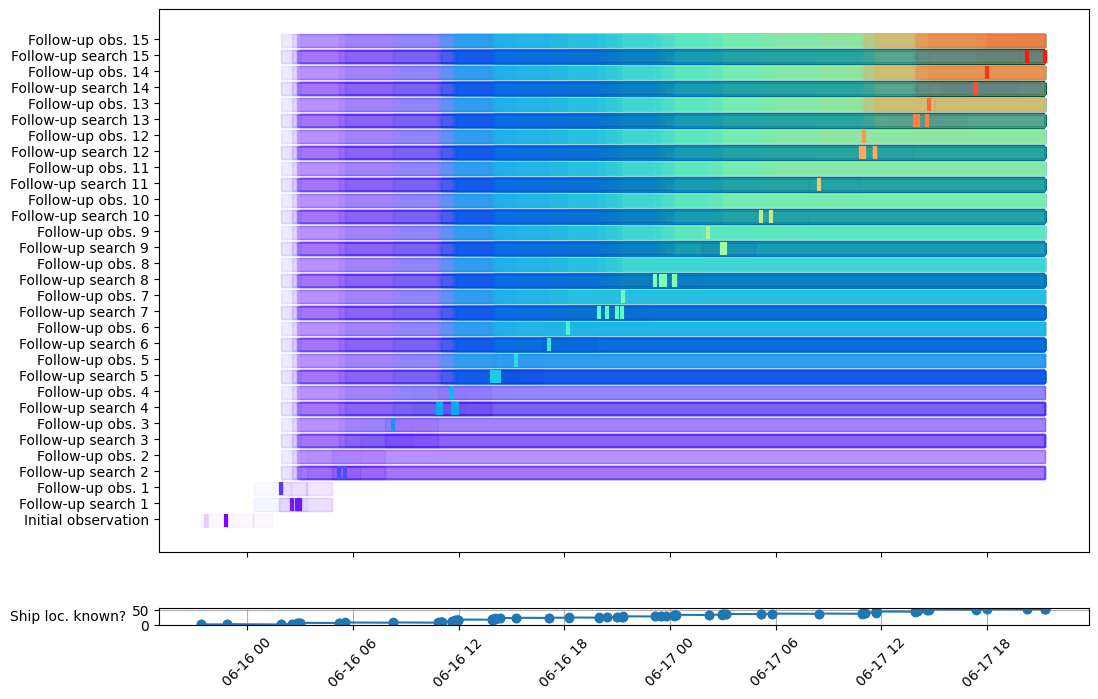

In [101]:
workflow_msa_priority = Workflow(
    constrained_observation_requests=workflow_msa_reqs,
    timelines = [ship_location_timeline_msa,],
    timeline_updater=timeline_updater_msa,
    request_updater=workflow_updater_msa,
)

wg_msa_priority, tg_msa_priority = build_workflow_graph(workflow=workflow_msa_priority)

wg_msa_priority = greedy_schedule_workflow(
    workflow_graph=wg_msa_priority,
    timeline_graph=tg_msa_priority,
    satellites=all_satellites,
    verbose=3,
    # feasibility_screener=
    )

plot_workflow_schedule(wg_msa_priority, tg_msa_priority)

In [102]:
find_dispatchable_tasks(wg_msa_priority, tg_msa_priority, verbose=99)

     [Dispatcher] Request Follow-up search 1.0 not dispatchable (parent Initial observation scheduled True, dispatched False, completed False). Constraint: ConstraintClass.TEMPORAL TemporalConstraintType.START_AFTER_OFFSET
     [Dispatcher] Request Follow-up search 1.1 not dispatchable (parent Initial observation scheduled True, dispatched False, completed False). Constraint: ConstraintClass.TEMPORAL TemporalConstraintType.START_AFTER_OFFSET
     [Dispatcher] Request Follow-up search 1.2 not dispatchable (parent Initial observation scheduled True, dispatched False, completed False). Constraint: ConstraintClass.TEMPORAL TemporalConstraintType.START_AFTER_OFFSET
     [Dispatcher] Request Follow-up search 1.3 not dispatchable (parent Initial observation scheduled True, dispatched False, completed False). Constraint: ConstraintClass.TEMPORAL TemporalConstraintType.START_AFTER_OFFSET
     [Dispatcher] Request Follow-up search 1.4 not dispatchable (parent Initial observation scheduled True, 

[Initial observation]